In [1]:
%loadlibs
from scipy.integrate import solve_ivp
torch.set_default_dtype(torch.float32)
torch.set_default_device('mps')

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


The equation reads
\begin{equation}
    \begin{align}
        &\frac{\partial x}{\partial t} = \sigma(y-x)\\
        &\frac{\partial y}{\partial t} = x(\rho -z) - y\\
        &\frac{\partial z}{\partial t} = xy - \beta z
    \end{align}
\end{equation}
where $\sigma=10$, $\beta=\frac{8}{3}$ and $\rho=28$.

In [2]:
%matplotlib inline

In [3]:
SIGMA = 10.0
BETA = 8.0/3.0
RHO = 28.0

def system(t, state, sigma=SIGMA, rho=RHO, beta=BETA):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho-z) -y
    dzdt = x*y - beta * z
    return [dxdt, dydt, dzdt]

In [4]:
tmax = 1.
t0 = 0.
x0, y0, z0 = 1., 1., 1.
n_points = 1000

In [5]:
def integrate_trajectory(x0, y0, z0, t0=t0, t_max=tmax, n_points=n_points, sigma=SIGMA, rho=RHO, beta=BETA):
    t_span = (t0, t_max)
    t_eval = np.linspace(0.0, t_max, 1000)
    sol = solve_ivp(
        system, t_span, [x0, y0, z0],
        args=(sigma, rho, beta),
        t_eval=t_eval,
        method="RK45",
        rtol=1e-9, atol=1e-9,
        dense_output=False,
    )
    return (torch.tensor(sol.t[::1000//n_points], dtype=torch.float32), 
            torch.tensor(sol.y[0][::1000//n_points], dtype=torch.float32), 
            torch.tensor(sol.y[1][::1000//n_points], dtype=torch.float32),
            torch.tensor(sol.y[2][::1000//n_points], dtype=torch.float32))

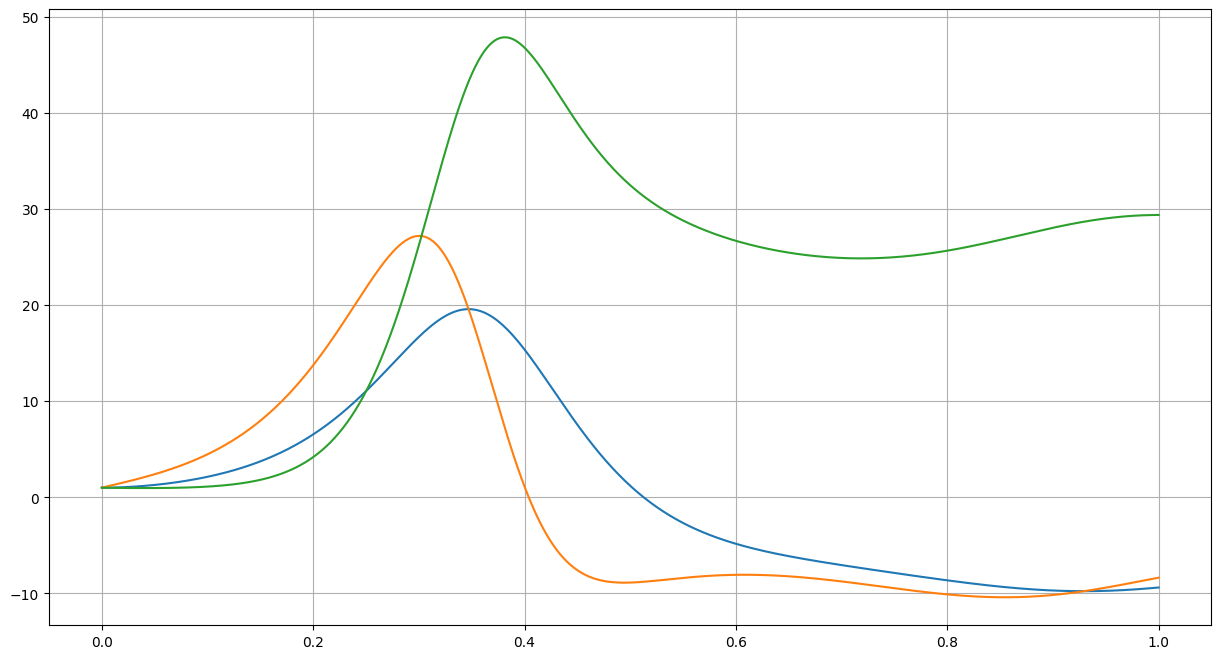

In [6]:
t_ref, x_ref, y_ref, z_ref = integrate_trajectory(x0, y0, z0)
plt.figure(figsize=(15, 8))
plt.plot(t_ref.cpu(), x_ref.cpu())
plt.plot(t_ref.cpu(), y_ref.cpu())
plt.plot(t_ref.cpu(), z_ref.cpu())
plt.grid()
plt.show()

In [9]:
class PINN(nn.Module):
    def __init__(self, layer_size, n_hidden_layers=4):
        super().__init__()
        self.layer_size = layer_size
        self.n_hidden_layers = n_hidden_layers
        self.l1 = nn.Linear(4, self.layer_size)
        self.h = nn.ModuleList([nn.Linear(self.layer_size, self.layer_size) for _ in range(self.n_hidden_layers)])
        self.l2 = nn.Linear(self.layer_size, 3)
        self.activation = nn.SiLU()

    def apply_ic(self, t, raw_out, t_0, ic):
        a, b, c = ic[:, 0:1], ic[:, 1:2], ic[:, 2:3]
        envelope = t-t_0
        x = a + envelope * raw_out[..., 0:1]
        y = b + envelope * raw_out[..., 1:2]
        z = c + envelope * raw_out[..., 2:3]
        return torch.cat([x, y, z], dim=-1)
    
    def forward(self, t, t_0, ic):
        a, b, c = ic[:, 0:1], ic[:, 1:2], ic[:, 2:3]
        x = self.activation(self.l1(torch.concatenate([a, b, c, t], axis=-1)))
        for i in range(self.n_hidden_layers):
            x = self.activation(self.h[i](x))
        return self.apply_ic(t, self.l2(x), t_0, ic)

def pde_loss(outputs, t):
    x, y, z = outputs[..., 0:1], outputs[..., 1:2], outputs[..., 2:3]
    dx_dt = torch.autograd.grad(x, t, torch.ones_like(t), create_graph=True)[0]
    dy_dt = torch.autograd.grad(y, t, torch.ones_like(t), create_graph=True)[0]
    dz_dt = torch.autograd.grad(z, t, torch.ones_like(t), create_graph=True)[0]
    rht1 = SIGMA * (y-x)
    rht2 = x * (RHO-z) - y
    rht3 = x * y - BETA * z
    return (((dx_dt-rht1)**2) + ((dy_dt-rht2)**2) + ((dz_dt-rht3)**2)).mean()
    
model = PINN(layer_size=64, n_hidden_layers=4)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=500, min_lr=1e-5)
n_points = 2**13
t_0 = torch.tensor(np.array(t0), dtype=torch.float32)
t_max = torch.tensor(np.array(tmax), dtype=torch.float32)

n_epochs = 20000
for e in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t = t_0 + torch.rand((n_points, 1), requires_grad=True) * (t_max - t_0)
    ic = (torch.rand((n_points, 3), requires_grad=True) - 0.5) * 3
    outputs = model(t, t_0, ic)
    loss = pde_loss(outputs, t)
    std_loss = 1000/torch.std(outputs)+0.01
    if loss < std_loss:
        loss = std_loss
    loss.backward()
    optimizer.step()
    scheduler.step(loss.item())
    pbar.set_description(f"Loss: {loss.item():.5e} - lr: {optimizer.param_groups[0]['lr']:.3e}")

  0%|          | 0/20000 [00:00<?, ?it/s]

KeyboardInterrupt: 

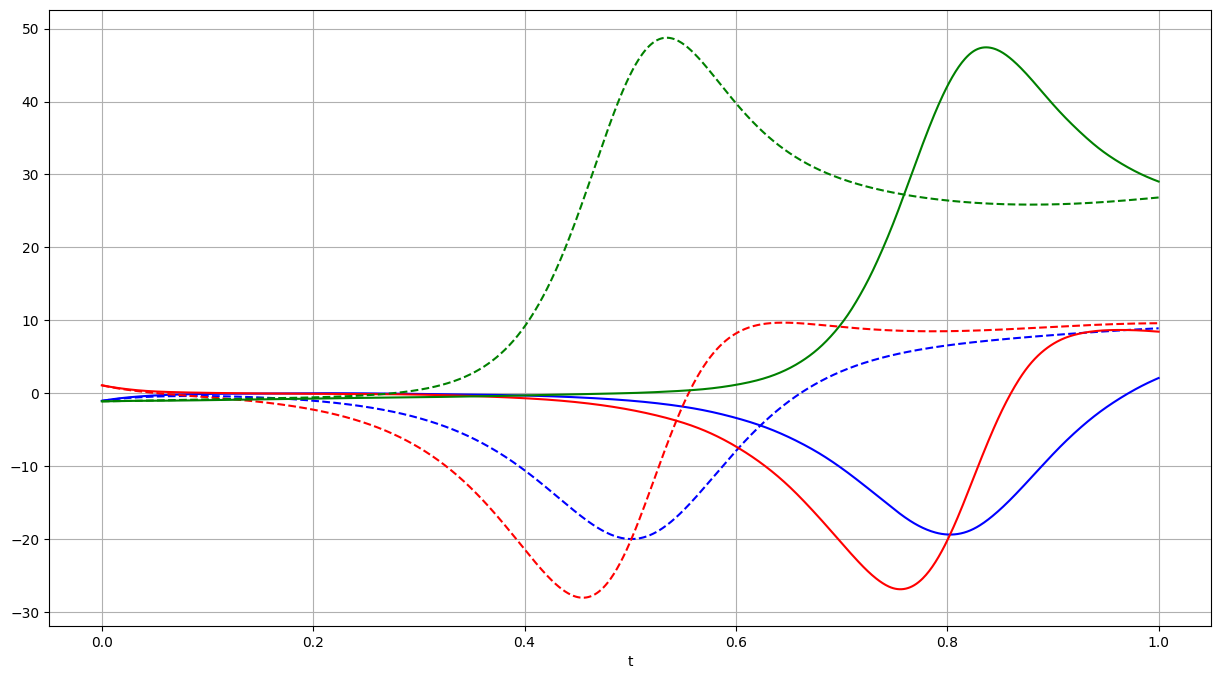

In [8]:
t = torch.linspace(0, t_max, 1000).unsqueeze(-1)
outputs = model(t, t_0, ic[0:1].repeat(1000, 1)).cpu().detach().numpy()
x, y, z = outputs[..., 0:1], outputs[..., 1:2], outputs[..., 2:3]
t_ref, x_ref, y_ref, z_ref = integrate_trajectory(*ic[0].cpu().detach())
plt.figure(figsize=(15, 8))
plt.plot(t.cpu(), x, color='blue')
plt.plot(t_ref.cpu(), x_ref.cpu(), linestyle='--', color='blue')
plt.plot(t.cpu(), y, color='red')
plt.plot(t_ref.cpu(), y_ref.cpu(), linestyle='--', color='red')
plt.plot(t.cpu(), z, color='green')
plt.plot(t_ref.cpu(), z_ref.cpu(), linestyle='--', color='green')
plt.xlabel('t')
plt.grid()
plt.show()